In [ ]:
# Make GETM Transect Animation (xarray + matplotlib)

# This notebook extracts a fixed-longitude transect from a GETM/ERSEM NetCDF file

# and builds an animated section plot over time.

In [ ]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML

In [ ]:
# ------------------------------ User settings ------------------------------
NETCDF_PATH = Path("/export/lv9/user/qzhan/model_output/active_runs/dws_200m/dws_200m/32x32/3d_merged_1d.nc")
OUTPUT_GIF = Path("/export/lv9/user/qzhan/model_output/active_runs/movie/transect_temp.gif")

PLOTVAR = "temp"
INDEX_LON_TRANSECT = 388
LAT_START = 240
LAT_STOP = 392
TIME_STEP = 4

VMIN = 3
VMAX = 6
CMAP = "nipy_spectral"

# ------------------------------ Helpers -----------------------------------
def _find_time_dim(da: xr.DataArray) -> str:
    for dim in da.dims:
        if "time" in dim.lower():
            return dim
    raise ValueError(f"No time-like dimension found in {da.dims}")


def _find_vertical_dim(da: xr.DataArray, time_dim: str) -> str:
    candidates = ("z", "sigma", "layer", "level", "lev", "depth", "nmesh2_layer_3d")
    for dim in da.dims:
        if dim == time_dim:
            continue
        if any(key in dim.lower() for key in candidates):
            return dim
    # Fallback: assume second dimension is vertical for 4D fields [time, z, y, x]
    if len(da.dims) >= 3:
        return da.dims[1]
    raise ValueError(f"No vertical-like dimension found in {da.dims}")


def _find_xy_dims(da: xr.DataArray, time_dim: str, z_dim: str) -> tuple[str, str]:
    remain = [d for d in da.dims if d not in (time_dim, z_dim)]
    if len(remain) != 2:
        raise ValueError(
            f"Expected 2 horizontal dims after removing time/z, got {remain} from {da.dims}"
        )
    return remain[0], remain[1]


def _pick_coord_name(ds: xr.Dataset, candidates: tuple[str, ...]) -> str | None:
    for name in candidates:
        if name in ds.variables:
            return name
    return None


def extract_transect(
    ds: xr.Dataset,
    var_name: str,
    i_lon: int,
    lat_start: int,
    lat_stop: int,
    lon_name_candidates: tuple[str, ...] = ("lonc", "lon", "longitude"),
    lat_name_candidates: tuple[str, ...] = ("latc", "lat", "latitude"),
) -> dict[str, xr.DataArray]:
    da = ds[var_name]
    time_dim = _find_time_dim(da)
    z_dim = _find_vertical_dim(da, time_dim)
    y_dim, x_dim = _find_xy_dims(da, time_dim, z_dim)

    transect = da.isel({x_dim: i_lon, y_dim: slice(lat_start, lat_stop)})

    lat_name = _pick_coord_name(ds, lat_name_candidates)
    if lat_name is None:
        raise KeyError(f"Could not find latitude variable among {lat_name_candidates}")

    lat_da = ds[lat_name]
    if y_dim in lat_da.dims and x_dim in lat_da.dims:
        lat_line = lat_da.isel({x_dim: i_lon, y_dim: slice(lat_start, lat_stop)})
    elif y_dim in lat_da.dims:
        lat_line = lat_da.isel({y_dim: slice(lat_start, lat_stop)})
    else:
        raise ValueError(f"Latitude variable '{lat_name}' does not match transect dims")

    if "h" in ds.variables:
        h = ds["h"].isel({x_dim: i_lon, y_dim: slice(lat_start, lat_stop)})
        if z_dim in h.dims:
            depth = -h.cumsum(dim=z_dim)
        else:
            depth = None
    else:
        depth = None

    return {
        "transect": transect,
        "lat_line": lat_line,
        "depth": depth,
        "time_dim": transect.dims[0],
        "z_dim": z_dim,
        "y_dim": y_dim,
    }

49
(49, 16, 512, 832)
longname temperature
157768200.0
2015-01-01 00:30:00
2015-01-01 
(49, 16, 152)
(152,)


TypeError: axis() takes from 0 to 1 positional arguments but 2 were given

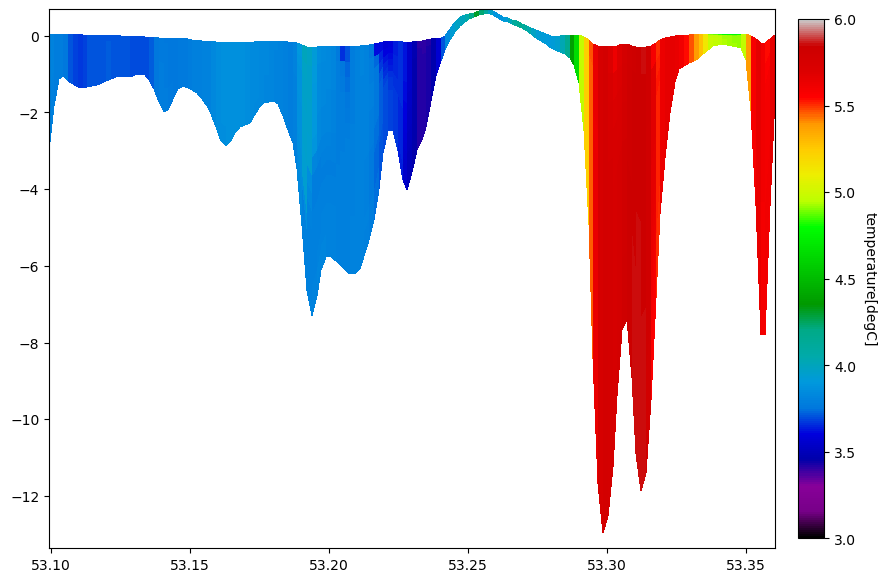

In [ ]:
ds = xr.open_dataset(NETCDF_PATH, decode_times=True)
pack = extract_transect(
    ds=ds,
    var_name=PLOTVAR,
    i_lon=INDEX_LON_TRANSECT,
    lat_start=LAT_START,
    lat_stop=LAT_STOP,
    lon_name_candidates=("lonc", "lon", "longitude"),
    lat_name_candidates=("latc", "lat", "latitude"),
)

transect = pack["transect"]
lat_line = pack["lat_line"]
depth = pack["depth"]
time_dim = pack["time_dim"]
z_dim = pack["z_dim"]
y_dim = pack["y_dim"]

times = transect[time_dim]
frame_indices = np.arange(0, transect.sizes[time_dim], TIME_STEP)

if len(frame_indices) == 0:
    raise ValueError("No frames selected. Check TIME_STEP and input time dimension length.")

fig, ax = plt.subplots(figsize=(10, 5))
plt.close(fig)  # Avoid duplicate static display in notebooks


def _get_xy_and_values(frame_idx: int):
    frame = transect.isel({time_dim: frame_idx})
    frame = frame.transpose(z_dim, y_dim)

    x2d = np.broadcast_to(np.asarray(lat_line)[None, :], frame.shape)

    if depth is not None:
        z2d = depth.isel({time_dim: frame_idx}).transpose(z_dim, y_dim).values
    else:
        # Fallback depth coordinate if layer thickness is not available
        z_levels = -np.arange(frame.shape[0], dtype=float)
        z2d = np.broadcast_to(z_levels[:, None], frame.shape)

    return x2d, z2d, frame.values


def update(frame_number: int):
    frame_idx = int(frame_indices[frame_number])
    x2d, z2d, values = _get_xy_and_values(frame_idx)

    ax.clear()
    mesh = ax.pcolormesh(
        x2d,
        z2d,
        values,
        shading="auto",
        cmap=CMAP,
        vmin=VMIN,
        vmax=VMAX,
    )

    timestamp = np.asarray(times.isel({time_dim: frame_idx}).values)
    ax.set_title(f"{PLOTVAR} transect | {timestamp}")
    ax.set_xlabel("Latitude")
    ax.set_ylabel("Depth (m)")

    return (mesh,)


ani = FuncAnimation(
    fig,
    update,
    frames=len(frame_indices),
    interval=150,
    blit=False,
    repeat=False,
  )

HTML(ani.to_jshtml())

OUTPUT_GIF.parent.mkdir(parents=True, exist_ok=True)
ani.save(OUTPUT_GIF, writer=PillowWriter(fps=6))
print(f"Saved animation to: {OUTPUT_GIF}")

ds.close()

In [ ]:
# Optional quick check:
print("Variable:", PLOTVAR)
print("Input file:", NETCDF_PATH)
print("Output GIF:", OUTPUT_GIF)